## **Customer Segmentation Analysis (RFM)**

### **Project Overview**
This project aims to segment customers based on their purchasing behavior using the **RFM (Recency, Frequency, Monetary)** model. By analyzing these metrics, we can identify different customer groups such as "Champions", "Loyal Customers", "At Risk", and "Hibernating" to optimize marketing strategies.

### **Phase 1: Data Preparation & Cleaning**
In this section, we implement a robust and modular approach to load and clean the dataset. By encapsulating our data pipeline into a Python Class (`DataPipeline`), we ensure our code is reusable, scalable, and adheres to industry-standard software engineering practices.

**Key Cleaning Steps:**
1. Dropping records with missing `CustomerID`.
2. Removing cancelled transactions (where `InvoiceNo` starts with 'C').
3. Filtering out anomalies (e.g., `Quantity` or `UnitPrice` <= 0).
4. Engineering the `TotalPrice` feature for monetary calculations.

In [ ]:
import pandas as pd
import numpy as np

class DataPreprocessor:
    """
    A modular pipeline class to handle data ingestion, cleaning, 
    and preprocessing for RFM Customer Segmentation.
    """
    
    def __init__(self, file_path: str):
        self.file_path = file_path
        self.df = None

    def process_data(self) -> pd.DataFrame:
        """
        Executes the end-to-end loading and cleaning process.
        
        Returns:
            pd.DataFrame: The cleaned and preprocessed dataset.
        """
        print(f"[*] Loading dataset from: {self.file_path}")
        try:
            self.df = pd.read_csv(self.file_path, encoding="utf-8")
            print("[+] Dataset loaded successfully.")
        except Exception as e:
            print(f"[-] Error loading dataset: {e}")
            return None

        initial_rows = self.df.shape[0]
        print(f"[*] Initial raw data shape: {self.df.shape}")
        print("[*] Initiating data cleaning protocol...")

        # 1. Drop missing customer_id
        self.df.dropna(subset=['customer_id'], inplace=True)
        
        # 2. Remove Cancelled Orders ('order_id' starts with 'C')
        self.df['order_id'] = self.df['order_id'].astype(str)
        self.df = self.df[~self.df['order_id'].str.startswith('C')]
        
        # 3. Filter out invalid negative or zero values
        self.df = self.df[(self.df['quantity'] > 0) & (self.df['price'] > 0)]
        
        # 4. Calculate Total Revenue
        self.df['total_revenue'] = self.df['quantity'] * self.df['price']
        
        # 5. Parse Dates
        self.df['order_date'] = pd.to_datetime(self.df['order_date'])
        
        # 6. Ensure customer_id is integer (optional but cleaner)
        self.df['customer_id'] = self.df['customer_id'].astype(int)
        
        final_rows = self.df.shape[0]
        retained_percentage = (final_rows / initial_rows) * 100
        
        print("[+] Data cleaning completed.")
        print(f"[+] Cleaned data shape: {self.df.shape}")
        print(f"[+] Data retained: {retained_percentage:.2f}%\n")
        
        return self.df

# ==========================================
# EXECUTION BLOCK
# ==========================================
FILE_PATH = 'Online Retail Data.csv' 
preprocessor = DataPreprocessor(FILE_PATH)
df_clean = preprocessor.process_data()

if df_clean is not None:
    display(df_clean.head())

[*] Loading dataset from: Online Retail Data.csv
[+] Dataset loaded successfully.
[*] Initial raw data shape: (461773, 7)
[*] Initiating data cleaning protocol...
[+] Data cleaning completed.
[+] Cleaned data shape: (352897, 8)
[+] Data retained: 76.42%



,order_id,product_code,product_name,quantity,order_date,price,customer_id,total_revenue
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346,22.5
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346,22.5
6,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590,91.8
7,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590,51.0
8,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590,5.1


### **Phase 2: RFM Feature Engineering & Advanced Segmentation**

In this phase, we transform the transactional dataset into customer-centric metrics:
* **Recency (R):** Days since the customer's last purchase.
* **Frequency (F):** Total number of distinct transactions.
* **Monetary (M):** Total revenue generated by the customer.

**The Upgrade:**
Standard RFM segmentation often relies solely on Recency and Frequency to define segments (e.g., 'Champions', 'At Risk'). Here, we introduce a `Value_Tier` based on the Monetary score. By combining the base segment with the Monetary tier (e.g., 'High Value At Risk'), we provide highly actionable insights for targeted marketing campaigns and budget allocation.

In [2]:
import datetime as dt
import numpy as np

class RFMEngine:
    """
    A class to calculate RFM metrics, compute quintile scores, 
    and assign advanced actionable business segments.
    """
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.rfm = None

    def generate_rfm(self) -> pd.DataFrame:
        """
        Executes the full RFM calculation and segmentation pipeline.
        """
        print("[*] Initializing RFM calculations...")
        snapshot_date = self.df['order_date'].max() + dt.timedelta(days=1)
        
        # 1. Calculate base RFM metrics
        self.rfm = self.df.groupby('customer_id').agg({
            'order_date': lambda x: (snapshot_date - x.max()).days,
            'order_id': 'nunique',
            'total_revenue': 'sum'
        }).reset_index()
        
        self.rfm.rename(columns={
            'order_date': 'recency',
            'order_id': 'frequency',
            'total_revenue': 'monetary'
        }, inplace=True)
        
        print(f"[+] RFM metrics computed for {self.rfm.shape[0]} unique customers.")
        
        # 2. Compute RFM Scores using Quantiles (1-5 scale)
        print("[*] Computing RFM quintile scores...")
        self.rfm['r_score'] = pd.qcut(self.rfm['recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1])
        self.rfm['f_score'] = pd.qcut(self.rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
        self.rfm['m_score'] = pd.qcut(self.rfm['monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
        
        # Concatenate R and F scores for standard mapping
        self.rfm['rf_score'] = self.rfm['r_score'].astype(str) + self.rfm['f_score'].astype(str)
        
        # 3. Assign Segments using Regex Mapping
        print("[*] Mapping standard RF segments...")
        seg_map = {
            r'[1-2][1-2]': 'Hibernating',
            r'[1-2][3-4]': 'At Risk',
            r'[1-2]5': 'Cannot Lose Them',
            r'3[1-2]': 'About To Sleep',
            r'33': 'Need Attention',
            r'[3-4][4-5]': 'Loyal Customers',
            r'41': 'Promising',
            r'51': 'New Customers',
            r'[4-5][2-3]': 'Potential Loyalists',
            r'5[4-5]': 'Champions'
        }
        self.rfm['base_segment'] = self.rfm['rf_score'].replace(seg_map, regex=True)
        
        # 4. The Business Value Add: Monetary Tiering
        print("[*] Applying Monetary Value Tiering...")
        self.rfm['value_tier'] = np.where(self.rfm['m_score'].astype(int) >= 4, 'High Value', 'Standard Value')
        self.rfm['actionable_segment'] = self.rfm['value_tier'] + ' ' + self.rfm['base_segment']
        
        print("[+] RFM Pipeline completed successfully.\n")
        return self.rfm

# ==========================================
# EXECUTION BLOCK
# ==========================================
rfm_engine = RFMEngine(df_clean)
df_rfm = rfm_engine.generate_rfm()
display(df_rfm[['customer_id', 'recency', 'frequency', 'monetary', 'base_segment', 'actionable_segment']].head(10))

[*] Initializing RFM calculations...
[+] RFM metrics computed for 3887 unique customers.
[*] Computing RFM quintile scores...
[*] Mapping standard RF segments...
[*] Applying Monetary Value Tiering...
[+] RFM Pipeline completed successfully.



,customer_id,recency,frequency,monetary,base_segment,actionable_segment
0,12346,179,6,259.36,At Risk,Standard Value At Risk
1,12608,54,1,415.79,About To Sleep,Standard Value About To Sleep
2,12745,136,2,723.85,Hibernating,Standard Value Hibernating
3,12746,190,1,254.55,Hibernating,Standard Value Hibernating
4,12747,11,14,4396.24,Champions,High Value Champions
5,12748,1,155,23254.93,Champions,High Value Champions
6,12749,49,4,2806.48,Loyal Customers,High Value Loyal Customers
7,12777,107,1,519.45,Hibernating,Standard Value Hibernating
8,12819,108,1,540.52,Hibernating,Standard Value Hibernating
9,12820,47,6,1598.88,Loyal Customers,High Value Loyal Customers


### **Phase 3: Machine Learning Integration (K-Means Clustering)**

While heuristic RFM segmentation provides solid baseline rules, integrating Unsupervised Machine Learning allows us to discover hidden patterns in customer behavior without human bias. We employ **K-Means Clustering** to automatically group customers into distinct segments.

**Methodology:**
1. **Log Transformation:** RFM metrics are typically highly right-skewed. We apply a logarithmic transformation (`np.log1p`) to normalize the distribution.
2. **Standardization:** K-Means is a distance-based algorithm. We use `StandardScaler` to ensure all features (R, F, M) contribute equally to the distance calculation, preventing features with larger magnitudes (like Monetary) from dominating the model.
3. **Model Fitting:** We apply K-Means to cluster the customer base and generate a summary profile for each cluster to extract business insights.

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

class CustomerClustering:
    """
    A machine learning pipeline for clustering customers using K-Means.
    Includes data normalization (handling skewness) and model fitting.
    """
    
    def __init__(self, rfm_df: pd.DataFrame):
        self.rfm_df = rfm_df.copy()
        self.scaled_data = None
        self.kmeans_model = None
        
    def preprocess_for_ml(self):
        """
        Applies Log Transformation and Standardization to the RFM features.
        """
        print("[*] Preprocessing RFM data for Machine Learning...")
        
        # 1. Handle skewness with Log Transformation
        log_data = self.rfm_df[['recency', 'frequency', 'monetary']].copy()
        for col in log_data.columns:
            log_data[col] = np.log1p(log_data[col])
            
        # 2. Scale data to have mean=0 and variance=1
        scaler = StandardScaler()
        self.scaled_data = scaler.fit_transform(log_data)
        
        print("[+] Data log-transformed and scaled successfully.")
        return self.scaled_data
        
    def fit_kmeans(self, n_clusters: int = 4) -> pd.DataFrame:
        """
        Fits the K-Means algorithm and assigns clusters to the dataframe.
        """
        if self.scaled_data is None:
            print("[-] Error: Please run preprocess_for_ml() first.")
            return self.rfm_df
            
        print(f"[*] Fitting K-Means model with {n_clusters} clusters...")
        self.kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.kmeans_model.fit(self.scaled_data)
    
        self.rfm_df['ml_cluster'] = self.kmeans_model.labels_
        print("[+] K-Means clustering completed.")
        
        summary = self.rfm_df.groupby('ml_cluster').agg({
            'recency': 'mean',
            'frequency': 'mean',
            'monetary': ['mean', 'count']
        }).round(2)
        
        print("\n[+] Machine Learning Cluster Profiles (Averages):")
        display(summary)
        
        return self.rfm_df

# ==========================================
# EXECUTION BLOCK
# ==========================================
ml_pipeline = CustomerClustering(df_rfm)
ml_pipeline.preprocess_for_ml()
df_final = ml_pipeline.fit_kmeans(n_clusters=4)
display(df_final[['customer_id', 'actionable_segment', 'ml_cluster']].head(10))

[*] Preprocessing RFM data for Machine Learning...
[+] Data log-transformed and scaled successfully.
[*] Fitting K-Means model with 4 clusters...
[+] K-Means clustering completed.

[+] Machine Learning Cluster Profiles (Averages):


recency frequency monetary      
              mean      mean     mean count
ml_cluster                                 
0           204.93      1.42   357.85  1125
1            59.85      4.58  1748.99  1248
2            16.83     15.10  7726.44   521
3            45.74      1.59   413.65   993

,customer_id,actionable_segment,ml_cluster
0,12346,Standard Value At Risk,0
1,12608,Standard Value About To Sleep,3
2,12745,Standard Value Hibernating,0
3,12746,Standard Value Hibernating,0
4,12747,High Value Champions,2
5,12748,High Value Champions,2
6,12749,High Value Loyal Customers,1
7,12777,Standard Value Hibernating,0
8,12819,Standard Value Hibernating,0
9,12820,High Value Loyal Customers,1


### **Phase 4: Data Visualization & Strategic Business Recommendations**

In this final phase, we visualize the distribution of our advanced customer segments and machine learning clusters to extract actionable business insights.

### **Executive Summary & Action Plan:**

1. **High Value Champions & Loyal Customers:**
   * **Profile:** These are our most valuable assets. They buy frequently, recently, and spend the most.
   * **Action:** Do not offer heavy discounts; they already love the brand. Instead, offer VIP perks, early access to new products, or exclusive loyalty programs to make them feel appreciated and turn them into brand advocates.

2. **High Value At Risk & Hibernating:**
   * **Profile:** Customers who used to spend a lot and buy frequently but haven't returned in a long time.
   * **Action:** **High Priority!** Win them back with aggressive, personalized campaigns. Send targeted emails with "We miss you" significant discounts (e.g., 20% off) or bundle offers.

3. **Standard Value / Low Value Hibernating:**
   * **Profile:** Customers who rarely bought, spent very little, and haven't returned.
   * **Action:** Minimize marketing spend here to avoid negative ROI. Stop sending expensive physical catalogs or SMS. Keep them on a low-cost automated email pipeline.

4. **New Customers & Promising:**
   * **Profile:** Bought recently but only once or twice.
   * **Action:** Nurture them. Send welcome emails, onboarding guides, and a small incentive for their *second* purchase to build the habit.

[*] Generating Actionable Segment Distribution plot...


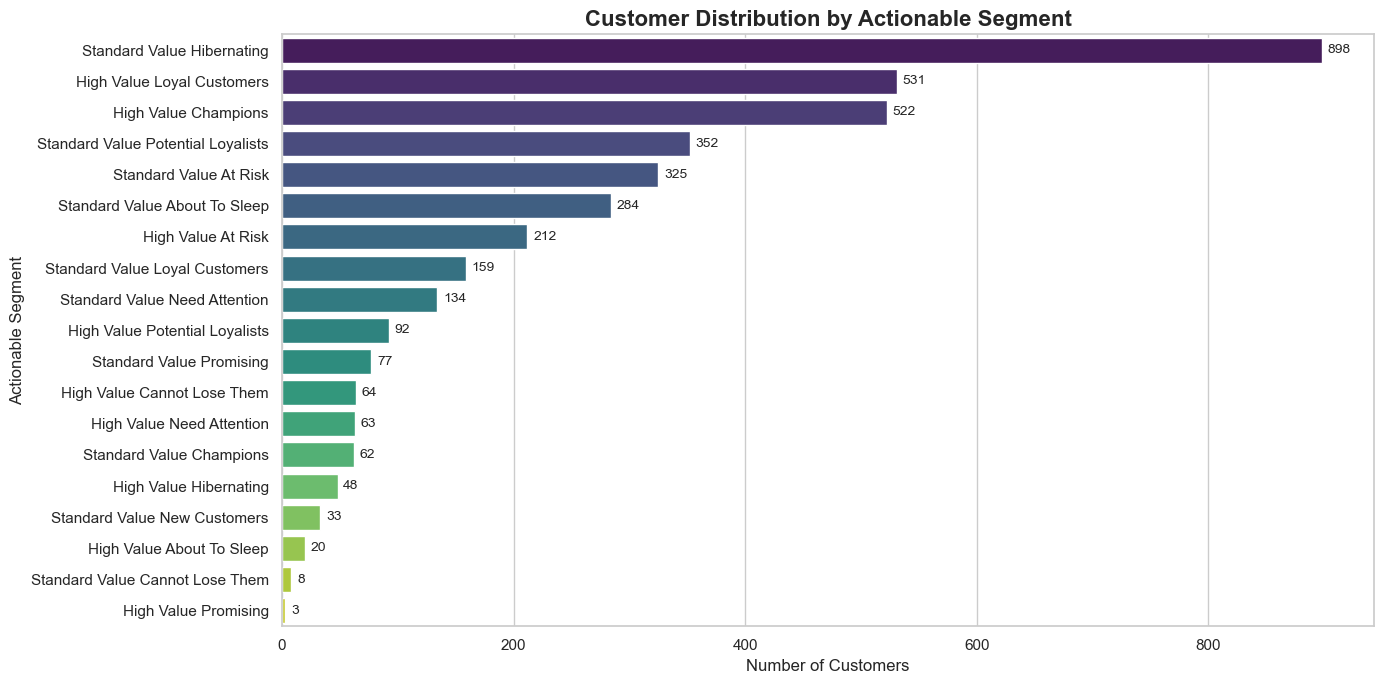

[*] Generating Machine Learning Clusters scatter plot...


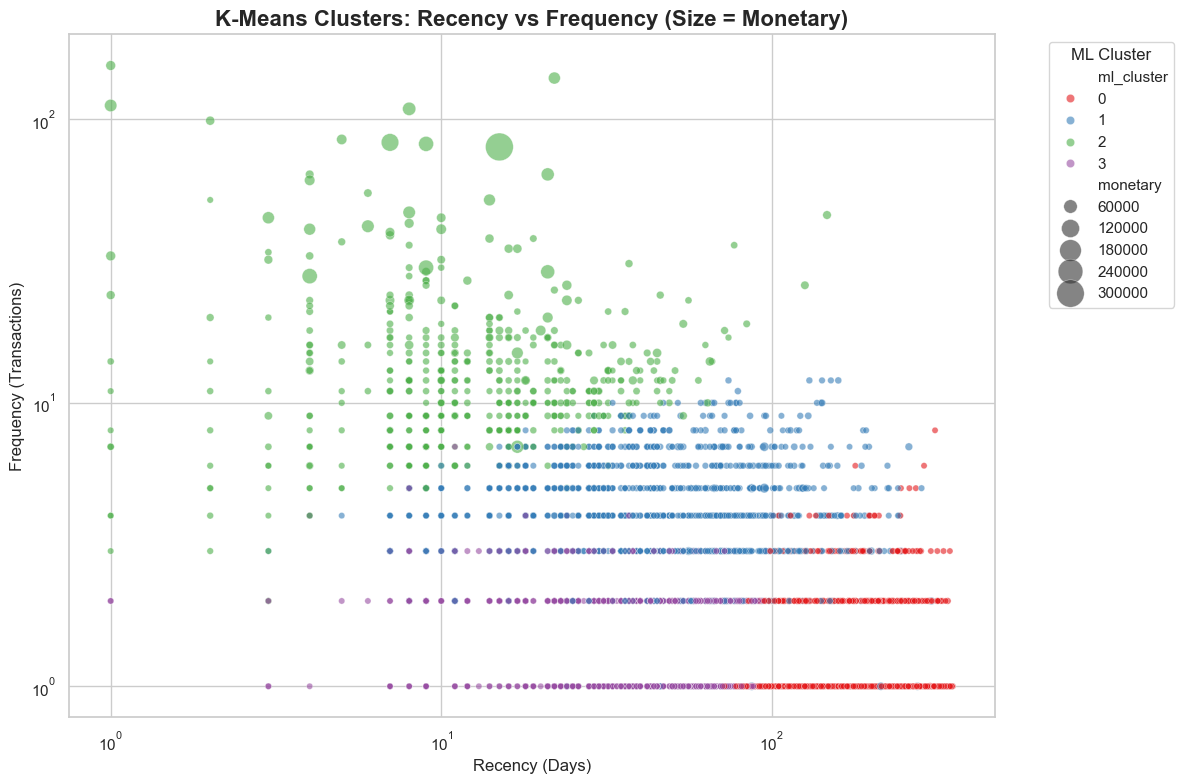

[+] All visualizations generated successfully. End of pipeline.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

class SegmentVisualizer:
    """
    A class dedicated to generating industry-standard visualizations 
    for RFM segments and Machine Learning clusters.
    """
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        sns.set_theme(style="whitegrid")
        plt.rcParams.update({'figure.autolayout': True})

    def plot_segment_distribution(self):
        """
        Plots a bar chart showing the count of customers in each actionable segment.
        """
        print("[*] Generating Actionable Segment Distribution plot...")
        plt.figure(figsize=(14, 7))
    
        segment_counts = self.df['actionable_segment'].value_counts().reset_index()
        segment_counts.columns = ['Segment', 'Count']
        
        ax = sns.barplot(
            data=segment_counts, 
            x='Count', 
            y='Segment', 
            palette='viridis',
            hue='Segment',
            legend=False
        )
        
        plt.title('Customer Distribution by Actionable Segment', fontsize=16, fontweight='bold')
        plt.xlabel('Number of Customers', fontsize=12)
        plt.ylabel('Actionable Segment', fontsize=12)
        
        for p in ax.patches:
            width = p.get_width()
            plt.text(width + 5, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{int(width)}', ha="left", fontsize=10)
            
        plt.show()

    def plot_ml_clusters_scatter(self):
        """
        Plots a scatter plot comparing Recency and Frequency, colored by ML Clusters.
        """
        print("[*] Generating Machine Learning Clusters scatter plot...")
        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            data=self.df, 
            x='recency', 
            y='frequency', 
            hue='ml_cluster', 
            palette='Set1',
            size='monetary',
            sizes=(20, 400),
            alpha=0.6
        )
        
        plt.title('K-Means Clusters: Recency vs Frequency (Size = Monetary)', fontsize=16, fontweight='bold')
        plt.xlabel('Recency (Days)', fontsize=12)
        plt.ylabel('Frequency (Transactions)', fontsize=12)
        
        plt.xscale('log')
        plt.yscale('log')
        
        plt.legend(title='ML Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

# ==========================================
# EXECUTION BLOCK
# ==========================================
visualizer = SegmentVisualizer(df_final)
visualizer.plot_segment_distribution()
visualizer.plot_ml_clusters_scatter()
print("[+] All visualizations generated successfully. End of pipeline.")